<a href="https://colab.research.google.com/github/NadiaTeta/group1/blob/main/notebooks/02_position_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install -q transformers
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

torch.manual_seed(42)   # so random results are the same for everyone
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# load the already-trained GPT-2 (small version) from Hugging Face
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained(
    "gpt2",
    output_attentions=True,         # lets us look at attention weights
    output_hidden_states=True,      # lets us look at the numbers after each layer
    attn_implementation="eager",    # needed so attention weights can be returned
).to(device)
model.eval()                        # we're exploring, not training

print("Device:", device)
print(f"GPT-2 loaded: {sum(p.numel() for p in model.parameters()) / 1e6:.0f} million parameters")

# shared example sentences: the same meaning in English and Kinyarwanda
english = "The people of Kicukiro say they have not had water for three days."
kinyarwanda = "Abaturage bo mu Kicukiro bavuga ko bamaze iminsi itatu nta mazi bafite."

for name, sentence in [("English", english), ("Kinyarwanda", kinyarwanda)]:
    tokens = tokenizer.tokenize(sentence)
    print(f"\n{name}: {len(tokens)} tokens")
    print(tokens)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Device: cpu
GPT-2 loaded: 124 million parameters

English: 17 tokens
['The', 'Ġpeople', 'Ġof', 'ĠK', 'ic', 'uk', 'iro', 'Ġsay', 'Ġthey', 'Ġhave', 'Ġnot', 'Ġhad', 'Ġwater', 'Ġfor', 'Ġthree', 'Ġdays', '.']

Kinyarwanda: 29 tokens
['Ab', 'atur', 'age', 'Ġbo', 'Ġmu', 'ĠK', 'ic', 'uk', 'iro', 'Ġb', 'av', 'uga', 'Ġko', 'Ġb', 'am', 'aze', 'Ġim', 'ins', 'i', 'Ġit', 'atu', 'Ġn', 'ta', 'Ġm', 'azi', 'Ġb', 'af', 'ite', '.']


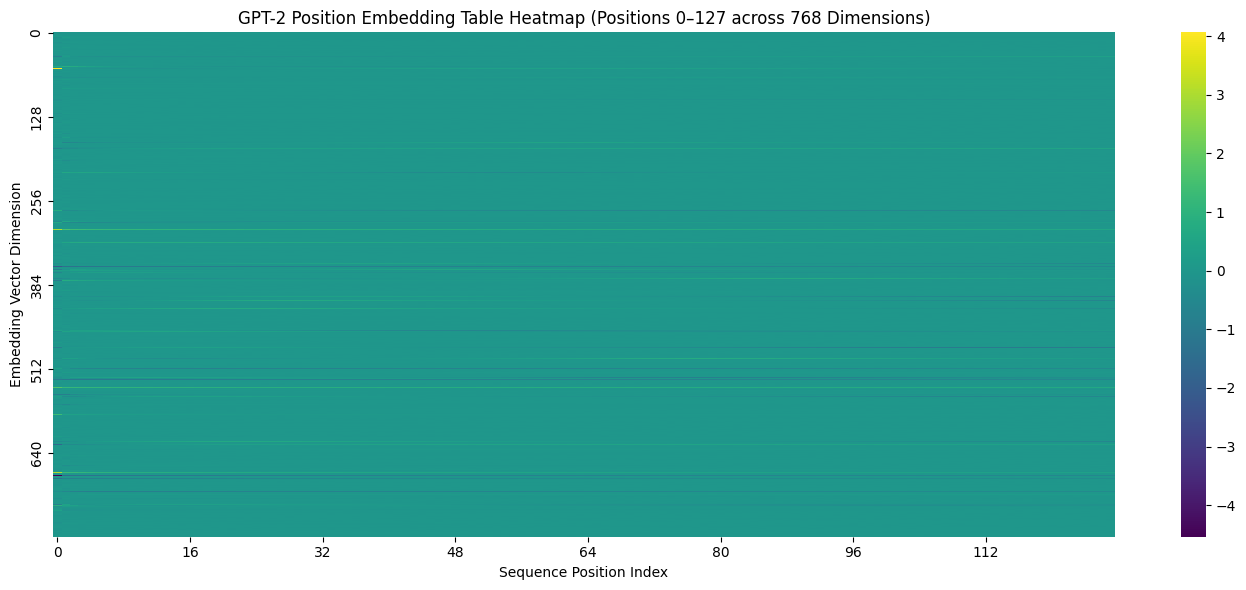


1. BEFORE SHUFFLING (Original Word Order)
Input: "The people of Kicukiro say they have not had water for three days."
Rank 1: '
' | Probability: 25.86%
Rank 2: ' They' | Probability: 10.46%
Rank 3: ' The' | Probability: 8.33%
Rank 4: ' It' | Probability: 3.00%
Rank 5: ' "' | Probability: 2.79%

2. AFTER SHUFFLING (Scrambled Word Order)
Input: "days three for water had not have they say Kicukiro of people The."
Rank 1: '
' | Probability: 4.03%
Rank 2: 'com' | Probability: 1.58%
Rank 3: ' The' | Probability: 1.54%
Rank 4: ' I' | Probability: 0.85%
Rank 5: ' He' | Probability: 0.71%

3. DIRECT POSITION EMBEDDING SCRAMBLING EXPERIMENT
Loss with correct positions [0..16]: 4.46
Loss with scrambled position_ids:    10.85


In [9]:

# Shared example sentence
english_original = "The people of Kicukiro say they have not had water for three days."
english_shuffled = "days three for water had not have they say Kicukiro of people The."


# ==============================================================================
# PART 1: Plot Heatmap of GPT-2's Position Embedding Table (1,024 positions)
# ==============================================================================
# Extract position embedding table weights (wpe: Word Position Embeddings)
pos_embedding_matrix = model.transformer.wpe.weight.detach().cpu().numpy()

plt.figure(figsize=(14, 6))
# Plotting first 128 positions across all 768 vector dimensions
sns.heatmap(
    pos_embedding_matrix[:128, :].T,
    cmap='viridis',
    cbar=True,
    xticklabels=16,
    yticklabels=128
)
plt.title("GPT-2 Position Embedding Table Heatmap (Positions 0–127 across 768 Dimensions)")
plt.xlabel("Sequence Position Index")
plt.ylabel("Embedding Vector Dimension")
plt.tight_layout()
plt.show()


# ==============================================================================
# PART 2: Next-Word Prediction Function & Shuffling Experiment
# ==============================================================================
def get_next_word_predictions(text, top_k=5):
    """Tokenizes text and returns the top-k predicted next tokens with probabilities."""
    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        # Get logits for the final position
        next_token_logits = outputs.logits[0, -1, :]
        probs = F.softmax(next_token_logits, dim=-1)

    top_probs, top_indices = torch.topk(probs, top_k)

    predictions = []
    for prob, idx in zip(top_probs, top_indices):
        token_str = tokenizer.decode(idx.item())
        predictions.append((token_str, prob.item() * 100))
    return predictions


print("\n" + "=" * 60)
print("1. BEFORE SHUFFLING (Original Word Order)")
print(f"Input: \"{english_original}\"")
print("=" * 60)
for rank, (token, prob) in enumerate(get_next_word_predictions(english_original), 1):
    print(f"Rank {rank}: '{token}' | Probability: {prob:.2f}%")

print("\n" + "=" * 60)
print("2. AFTER SHUFFLING (Scrambled Word Order)")
print(f"Input: \"{english_shuffled}\"")
print("=" * 60)
for rank, (token, prob) in enumerate(get_next_word_predictions(english_shuffled), 1):
    print(f"Rank {rank}: '{token}' | Probability: {prob:.2f}%")


# ==============================================================================
# PART 3: Position Index Permutation Loss Experiment
# ==============================================================================
# Keeps the tokens identical and in exact original order,
# but directly scrambles position_ids fed to the embedding layer.
inputs = tokenizer(english_original, return_tensors="pt").to(device)
n = inputs["input_ids"].shape[1]

with torch.no_grad():
    # Standard Loss calculation (0, 1, 2, ..., n-1)
    normal_loss = model(**inputs, labels=inputs["input_ids"]).loss.item()

    # Randomly permute the positional indices
    scrambled_positions = torch.randperm(n, device=device).unsqueeze(0)

    # Loss calculation with scrambled position_ids
    scrambled_loss = model(
        **inputs,
        position_ids=scrambled_positions,
        labels=inputs["input_ids"]
    ).loss.item()

print("\n" + "=" * 60)
print("3. DIRECT POSITION EMBEDDING SCRAMBLING EXPERIMENT")
print("=" * 60)
print(f"Loss with correct positions [0..{n-1}]: {normal_loss:.2f}")
print(f"Loss with scrambled position_ids:    {scrambled_loss:.2f}")